In [1]:
import numpy as np 
import pandas as pd 
import math
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn import metrics
from sklearn import svm
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.dummy import DummyClassifier
from imblearn.metrics import geometric_mean_score

In [2]:
data=pd.read_csv("glass.csv")

In [3]:
import sklearn
sklearn.__version__

'1.0.2'

In [4]:
data

,1,1.52101,13.64,4.49,1.1,71.78,0.06,8.75,0,0.1,1.1.1
0,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.00,1
1,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.00,1
2,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.00,1
3,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.00,1
4,6,1.51596,12.79,3.61,1.62,72.97,0.64,8.07,0.00,0.26,1
...,...,...,...,...,...,...,...,...,...,...,...
208,210,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.00,7
209,211,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.00,7
210,212,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.00,7
211,213,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.00,7


In [5]:
data.columns=["a","b","c","d","e","f","g","h","i","j","Class"]
data

,a,b,c,d,e,f,g,h,i,j,Class
0,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.00,1
1,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.00,1
2,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.00,1
3,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.00,1
4,6,1.51596,12.79,3.61,1.62,72.97,0.64,8.07,0.00,0.26,1
...,...,...,...,...,...,...,...,...,...,...,...
208,210,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.00,7
209,211,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.00,7
210,212,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.00,7
211,213,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.00,7


In [6]:
#data.drop('a', inplace=True, axis=1)

In [7]:
#data

In [8]:
data.Class = pd.factorize(data.Class)[0] + 1

In [9]:
gb=data.groupby("Class")

In [10]:
for Class, Class_df in gb:
    print(Class)
    print(Class_df)

1
     a        b      c     d     e      f     g      h    i     j  Class
0    2  1.51761  13.89  3.60  1.36  72.73  0.48   7.83  0.0  0.00      1
1    3  1.51618  13.53  3.55  1.54  72.99  0.39   7.78  0.0  0.00      1
2    4  1.51766  13.21  3.69  1.29  72.61  0.57   8.22  0.0  0.00      1
3    5  1.51742  13.27  3.62  1.24  73.08  0.55   8.07  0.0  0.00      1
4    6  1.51596  12.79  3.61  1.62  72.97  0.64   8.07  0.0  0.26      1
..  ..      ...    ...   ...   ...    ...   ...    ...  ...   ...    ...
64  66  1.52099  13.69  3.59  1.12  71.96  0.09   9.40  0.0  0.00      1
65  67  1.52152  13.05  3.65  0.87  72.22  0.19   9.85  0.0  0.17      1
66  68  1.52152  13.05  3.65  0.87  72.32  0.19   9.85  0.0  0.17      1
67  69  1.52152  13.12  3.58  0.90  72.20  0.23   9.82  0.0  0.16      1
68  70  1.52300  13.31  3.58  0.82  71.99  0.12  10.17  0.0  0.03      1

[69 rows x 11 columns]
2
       a        b      c     d     e      f     g     h     i     j  Class
69    71  1.51574  14

In [11]:
gb.get_group(1)

,a,b,c,d,e,f,g,h,i,j,Class
0,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.00,1
1,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.00,1
2,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.00,1
3,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.00,1
4,6,1.51596,12.79,3.61,1.62,72.97,0.64,8.07,0.0,0.26,1
...,...,...,...,...,...,...,...,...,...,...,...
64,66,1.52099,13.69,3.59,1.12,71.96,0.09,9.40,0.0,0.00,1
65,67,1.52152,13.05,3.65,0.87,72.22,0.19,9.85,0.0,0.17,1
66,68,1.52152,13.05,3.65,0.87,72.32,0.19,9.85,0.0,0.17,1
67,69,1.52152,13.12,3.58,0.90,72.20,0.23,9.82,0.0,0.16,1


In [12]:
class_samples=gb.get_group(1).sample(n=15)
#    print(class_samples)

In [13]:
print(type(class_samples))

<class 'pandas.core.frame.DataFrame'>


In [14]:
mean_sum=class_samples["b"].mean() + class_samples["c"].mean() + class_samples["d"].mean() + class_samples["e"].mean() + class_samples["f"].mean() + class_samples["g"].mean() + class_samples["h"].mean() + class_samples["i"].mean() + class_samples["j"].mean() 

In [15]:
column_length=len(data.columns) -1

In [16]:
similar_val_1=mean_sum/column_length
print(similar_val_1)

10.143561866666666


In [17]:
class_2_samples=gb.get_group(2).sample(n=15)
#    print(class_2_samples)

In [18]:
mean_sum_2=class_2_samples["b"].mean() + class_2_samples["c"].mean() + class_2_samples["d"].mean() + class_2_samples["e"].mean() + class_2_samples["f"].mean() + class_2_samples["g"].mean() + class_2_samples["h"].mean() + class_2_samples["i"].mean() + class_2_samples["j"].mean()

In [19]:
similar_val_2=mean_sum_2/column_length
print(similar_val_2)

10.135365266666668


In [20]:
class_3_samples=gb.get_group(3).sample(n=15)
#    print(class_3_samples)

In [21]:
mean_sum_3=class_3_samples["b"].mean() + class_3_samples["c"].mean() + class_3_samples["d"].mean() + class_3_samples["e"].mean() + class_3_samples["f"].mean() + class_3_samples["g"].mean() + class_3_samples["h"].mean() + class_3_samples["i"].mean() + class_3_samples["j"].mean()

In [22]:
similar_val_3=mean_sum_3/column_length
print(similar_val_3)

10.137882266666669


In [23]:
class_4_samples=gb.get_group(4).sample(n=13)

In [24]:
mean_sum_4=class_4_samples["b"].mean() + class_4_samples["c"].mean() + class_4_samples["d"].mean() + class_4_samples["e"].mean() + class_4_samples["f"].mean() + class_4_samples["g"].mean() + class_4_samples["h"].mean() + class_4_samples["i"].mean() + class_4_samples["j"].mean()

In [25]:
similar_val_4=mean_sum_4/column_length
print(similar_val_4)

10.136277384615386


In [26]:
class_5_samples=gb.get_group(5).sample(n=8)

In [27]:
mean_sum_5=class_5_samples["b"].mean() + class_5_samples["c"].mean() + class_5_samples["d"].mean() + class_5_samples["e"].mean() + class_5_samples["f"].mean() + class_5_samples["g"].mean() + class_5_samples["h"].mean() + class_5_samples["i"].mean() + class_5_samples["j"].mean()

In [28]:
similar_val_5=mean_sum_5/column_length
print(similar_val_5)

10.139471625000002


In [29]:
class_6_samples=gb.get_group(6).sample(n=15)

In [30]:
mean_sum_6=class_6_samples["b"].mean() + class_6_samples["c"].mean() + class_6_samples["d"].mean() + class_6_samples["e"].mean() + class_6_samples["f"].mean() + class_6_samples["g"].mean() + class_6_samples["h"].mean() + class_6_samples["i"].mean() + class_6_samples["j"].mean()

In [31]:
similar_val_6 = mean_sum_6/column_length
print(similar_val_6)

10.146886666666669


In [32]:
sim_23=abs(similar_val_3 - similar_val_2)
sim_23=sim_23/1000
sim_23=1 - sim_23

sim_24=abs(similar_val_2 - similar_val_4)
sim_24=sim_24/1000
sim_24=1 - sim_24

sim_25=abs(similar_val_2 - similar_val_5)
sim_25=sim_25/1000
sim_25=1 - sim_25

sim_26=abs(similar_val_2 - similar_val_6)
sim_26=sim_26/1000
sim_26=1 - sim_26

sim_12=abs(similar_val_1 - similar_val_2)
sim_12=sim_12/1000
sim_12=1 - sim_12

sim_13=abs(similar_val_3 - similar_val_1)
sim_13=sim_13/1000
sim_13=1 - sim_13

sim_14=abs(similar_val_1 - similar_val_4)
sim_14=sim_12/1000
sim_14=1 - sim_14

sim_15=abs(similar_val_1 - similar_val_5)
sim_15=sim_13/1000
sim_15=1 - sim_15

sim_16=abs(similar_val_1 - similar_val_6)
sim_16=sim_16/1000
sim_16=1 - sim_16

sim_34=abs(similar_val_3 - similar_val_4)
sim_34=sim_34/1000
sim_34=1 - sim_34

sim_35=abs(similar_val_3 - similar_val_5)
sim_35=sim_35/1000
sim_35=1 - sim_35

sim_36=abs(similar_val_3 - similar_val_6)
sim_36=sim_36/1000
sim_36=1 - sim_36

sim_45=abs(similar_val_4 - similar_val_5)
sim_45=sim_45/1000
sim_45=1 - sim_45

sim_46=abs(similar_val_4 - similar_val_6)
sim_46=sim_45/1000
sim_46=1 - sim_46

sim_56=abs(similar_val_5 - similar_val_6)
sim_56=sim_56/1000
sim_56=1 - sim_56


print("Similarity between 1 and 2: ", sim_12)
print("Similarity between 1 and 3: ", sim_13)
print("Similarity between 1 and 4: ", sim_14)
print("Similarity between 1 and 5: ", sim_15)
print("Similarity between 1 and 6: ", sim_16)

print("Similarity between 2 and 3: ", sim_23)
print("Similarity between 2 and 4: ", sim_24)
print("Similarity between 2 and 5: ", sim_25)
print("Similarity between 2 and 6: ", sim_26)

print("Similarity between 3 and 4: ", sim_34)
print("Similarity between 3 and 5: ", sim_35)
print("Similarity between 3 and 6: ", sim_36)

print("Similarity between 4 and 5: ", sim_45)
print("Similarity between 4 and 6: ", sim_46)

print("Similarity between 5 and 6: ", sim_56)

Similarity between 1 and 2:  0.9999918034
Similarity between 1 and 3:  0.9999943204
Similarity between 1 and 4:  0.9990000081966
Similarity between 1 and 5:  0.9990000056796
Similarity between 1 and 6:  0.9999966752
Similarity between 2 and 3:  0.999997483
Similarity between 2 and 4:  0.9999990878820513
Similarity between 2 and 5:  0.9999958936416666
Similarity between 2 and 6:  0.9999884786
Similarity between 3 and 4:  0.9999983951179487
Similarity between 3 and 5:  0.9999984106416666
Similarity between 3 and 6:  0.9999909956
Similarity between 4 and 5:  0.9999968057596154
Similarity between 4 and 6:  0.9990000031942404
Similarity between 5 and 6:  0.9999925849583333


In [33]:
gb.size()

Class
1    69
2    76
3    17
4    13
5     9
6    29
dtype: int64

In [34]:
m=math.ceil((76+9)/2)

In [35]:
print(m)

43


In [36]:
len(gb)

6

In [37]:
neigh = KNeighborsClassifier(n_neighbors=5)

In [38]:
#neigh.fit(X_train, Y_train)
neigh.fit(data, data.Class)

KNeighborsClassifier()

In [39]:
result=neigh.kneighbors(data, return_distance=True)

In [40]:
print(type(result))

<class 'tuple'>


In [41]:
print(result)

(array([[0.        , 1.11476547, 2.15638587, 3.09583592, 4.18163876],
       [0.        , 1.11476547, 1.24695717, 2.06888896, 3.12605183],
       [0.        , 1.12017858, 1.24695717, 2.1251595 , 2.15638587],
       ...,
       [0.        , 1.02441063, 1.20341782, 2.014302  , 2.51684714],
       [0.        , 1.02441063, 1.06498843, 2.14555357, 3.42019006],
       [0.        , 1.06498843, 2.014302  , 3.10306301, 4.23115833]]), array([[  0,   1,   2,   3,   4],
       [  1,   0,   2,   3,   4],
       [  2,   3,   1,   4,   0],
       ...,
       [210, 211, 209, 212, 208],
       [211, 210, 212, 209, 208],
       [212, 211, 210, 209, 208]], dtype=int64))


In [42]:
arr1=result[0]

In [43]:
print(type(arr1))

<class 'numpy.ndarray'>


In [44]:
print(arr1.ndim)

2


In [45]:
arr2=result[1]

In [46]:
print(type(arr2))

<class 'numpy.ndarray'>


In [47]:
print(arr1.ndim)

2


In [48]:
print(arr2)

[[  0   1   2   3   4]
 [  1   0   2   3   4]
 [  2   3   1   4   0]
 ...
 [210 211 209 212 208]
 [211 210 212 209 208]
 [212 211 210 209 208]]


In [49]:
print(arr1)

[[0.         1.11476547 2.15638587 3.09583592 4.18163876]
 [0.         1.11476547 1.24695717 2.06888896 3.12605183]
 [0.         1.12017858 1.24695717 2.1251595  2.15638587]
 ...
 [0.         1.02441063 1.20341782 2.014302   2.51684714]
 [0.         1.02441063 1.06498843 2.14555357 3.42019006]
 [0.         1.06498843 2.014302   3.10306301 4.23115833]]


In [50]:
#print(arr1)

In [51]:
print(arr1.size)

1065


In [52]:
#tHIS LINE TAKES THE SUMMATION OF A THE DISTANCE BETWEEN THE INSTANCE AND IT'S NEIGHBORS
addVal=[]
s=1
for i in arr1:
    _sum=int(i[0] + i[1] + i[2] + i[3] + i[4])
    addVal.append(_sum)
    print(i ," ", _sum, " ") 
    s=s+1

[0.         1.11476547 2.15638587 3.09583592 4.18163876]   10  
[0.         1.11476547 1.24695717 2.06888896 3.12605183]   7  
[0.         1.12017858 1.24695717 2.1251595  2.15638587]   6  
[0.         1.12017858 1.20942223 2.00556725 2.06888896]   6  
[0.         1.20942223 1.25944518 2.1251595  2.15146521]   6  
[0.         1.02868849 1.25944518 2.00556725 2.37451112]   6  
[0.         1.02868849 1.80130581 2.05399611 2.15146521]   7  
[0.         1.71242596 1.80130581 2.37451112 2.67602542]   8  
[0.         1.14241122 1.71242596 2.0225479  2.05399611]   6  
[0.         1.14241122 1.20416099 2.01506825 2.67602542]   7  
[0.         1.20416099 1.21445586 2.0225479  2.02940879]   6  
[0.         1.08415983 1.21445586 2.01506825 2.09258286]   6  
[0.         1.056551   1.08415983 2.00897984 2.02940879]   6  
[0.         1.03126136 1.056551   2.02659815 2.09258286]   6  
[0.         1.03126136 1.07359213 2.00897984 3.03855277]   7  
[0.         1.07359213 2.02659815 2.60980873 2.7210874

In [53]:
print(len(addVal))

213


In [54]:
#THE VALUE FOR THE SUMMATION OF ALL THE DISTANCES
print(addVal)

[10, 7, 6, 6, 6, 6, 7, 8, 6, 7, 6, 6, 6, 6, 7, 8, 10, 8, 8, 8, 11, 7, 7, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 8, 9, 8, 9, 8, 8, 7, 9, 8, 7, 8, 8, 7, 8, 8, 7, 7, 6, 6, 7, 7, 6, 6, 6, 7, 8, 7, 7, 6, 6, 6, 6, 7, 9, 12, 9, 7, 6, 6, 6, 6, 6, 7, 6, 7, 6, 7, 7, 9, 7, 7, 6, 6, 7, 8, 6, 6, 6, 7, 7, 8, 8, 7, 6, 6, 8, 11, 15, 14, 18, 21, 19, 17, 17, 13, 13, 15, 10, 7, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 8, 8, 8, 9, 10, 18, 10, 8, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 6, 6, 8, 8, 10, 8, 7, 6, 7, 7, 9, 6, 6, 7, 8, 11, 23, 13, 10, 10, 9, 10, 9, 11, 24, 24, 13, 12, 12, 9, 8, 8, 8, 13, 10, 12, 15, 23, 19, 16, 15, 14, 14, 12, 9, 8, 7, 7, 7, 7, 6, 6, 7, 8, 19, 8, 8, 7, 7, 8, 15, 9, 8, 7, 6, 7, 10]


In [55]:
arr3=np.array(addVal)

In [56]:
print(type(arr3))

<class 'numpy.ndarray'>


In [57]:
print(arr3.size)

213


In [58]:
print(arr3)

[10  7  6  6  6  6  7  8  6  7  6  6  6  6  7  8 10  8  8  8 11  7  7  6
  6  6  6  6  6  6  6  6  6  6  7  8  9  8  9  8  8  7  9  8  7  8  8  7
  8  8  7  7  6  6  7  7  6  6  6  7  8  7  7  6  6  6  6  7  9 12  9  7
  6  6  6  6  6  7  6  7  6  7  7  9  7  7  6  6  7  8  6  6  6  7  7  8
  8  7  6  6  8 11 15 14 18 21 19 17 17 13 13 15 10  7  6  6  6  6  6  6
  6  6  6  6  7  8  8  8  9 10 18 10  8  6  6  6  6  6  6  6  6  6  6  7
  7  7  6  6  8  8 10  8  7  6  7  7  9  6  6  7  8 11 23 13 10 10  9 10
  9 11 24 24 13 12 12  9  8  8  8 13 10 12 15 23 19 16 15 14 14 12  9  8
  7  7  7  7  6  6  7  8 19  8  8  7  7  8 15  9  8  7  6  7 10]


In [59]:
g=1
for i in addVal:
    print(g ," ", i) 
    g=g+1

1   10
2   7
3   6
4   6
5   6
6   6
7   7
8   8
9   6
10   7
11   6
12   6
13   6
14   6
15   7
16   8
17   10
18   8
19   8
20   8
21   11
22   7
23   7
24   6
25   6
26   6
27   6
28   6
29   6
30   6
31   6
32   6
33   6
34   6
35   7
36   8
37   9
38   8
39   9
40   8
41   8
42   7
43   9
44   8
45   7
46   8
47   8
48   7
49   8
50   8
51   7
52   7
53   6
54   6
55   7
56   7
57   6
58   6
59   6
60   7
61   8
62   7
63   7
64   6
65   6
66   6
67   6
68   7
69   9
70   12
71   9
72   7
73   6
74   6
75   6
76   6
77   6
78   7
79   6
80   7
81   6
82   7
83   7
84   9
85   7
86   7
87   6
88   6
89   7
90   8
91   6
92   6
93   6
94   7
95   7
96   8
97   8
98   7
99   6
100   6
101   8
102   11
103   15
104   14
105   18
106   21
107   19
108   17
109   17
110   13
111   13
112   15
113   10
114   7
115   6
116   6
117   6
118   6
119   6
120   6
121   6
122   6
123   6
124   6
125   7
126   8
127   8
128   8
129   9
130   10
131   18
132   10
133   8
134   6
135   6
136   6
1

In [60]:
newarr = arr3.reshape(213, 1)

In [61]:
print(newarr.ndim)

2


In [62]:
new_arr2=np.append(arr2, newarr, axis=1)

In [63]:
print(type(new_arr2))

<class 'numpy.ndarray'>


In [64]:
#FORM AN ARRAY THAT INCLUDES THE INDICE OF NEIGHBORS AND THE DISTANCE AS THE LAST INDICE
print(new_arr2)

[[  0   1   2   3   4  10]
 [  1   0   2   3   4   7]
 [  2   3   1   4   0   6]
 ...
 [210 211 209 212 208   6]
 [211 210 212 209 208   7]
 [212 211 210 209 208  10]]


In [65]:
print(new_arr2[0])

[ 0  1  2  3  4 10]


In [66]:
arr2

array([[  0,   1,   2,   3,   4],
       [  1,   0,   2,   3,   4],
       [  2,   3,   1,   4,   0],
       ...,
       [210, 211, 209, 212, 208],
       [211, 210, 212, 209, 208],
       [212, 211, 210, 209, 208]], dtype=int64)

In [67]:
print(new_arr2[0][1],  new_arr2[0][2],  new_arr2[0][3], new_arr2[0][4],new_arr2[0][5])

1 2 3 4 10


In [68]:
data

,a,b,c,d,e,f,g,h,i,j,Class
0,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.00,1
1,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.00,1
2,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.00,1
3,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.00,1
4,6,1.51596,12.79,3.61,1.62,72.97,0.64,8.07,0.00,0.26,1
...,...,...,...,...,...,...,...,...,...,...,...
208,210,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.00,6
209,211,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.00,6
210,212,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.00,6
211,213,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.00,6


In [69]:
# Creating and populating a dictionary with the 'key' as key and class value as value
new_dist={}
for i, v in data.Class.iteritems():
    new_dist[i]=v

In [70]:
#print(new_dist)

In [71]:
# Creating and populating a dictionary with the 's=0 to end' as key and class value as value
new_dist2={}
s=0
for i, v in data.Class.iteritems():
    new_dist2[s]=v
    s=s+1

In [72]:
#print(new_dist2)

In [73]:
# Creating and populating a dictionary with the 's=0 to end' as key and 'index value' as value
new_dist3={}
s=0
for i, v in data.Class.iteritems():
    new_dist3[s]=i
    s=s+1

In [74]:
#print(new_dist3)

In [75]:
#print(new_dist[204])

In [76]:
#new_dist3

<!-- Populating a dictionary  -->

In [77]:
    neigh_count=[]
    s=0
    for i, v in new_dist2.items():
        c1=0
        c2=0
        c3=0
        c4=0
        c5=0
        c6=0
        class_example=0
        
        if int(v) == 1:
            c1=c1+1
        elif int(v) == 2:
            c2=c2+1
        elif int(v) == 3:
            c3=c3+1
        elif int(v) == 4:
            c4=c4+1
        elif int(v) == 5:
            c5=c5+1
        else:
            c6=c6+1
            
        for x in range(1,5):
            if new_dist2[new_arr2[i][x]]==1:
                c1=c1+1
            elif new_dist2[new_arr2[i][x]]==2:
                c2=c2+1
            elif new_dist2[new_arr2[i][x]]==3:
                c3=c3+1
            elif new_dist2[new_arr2[i][x]]==4:
                c4=c4+1
            elif new_dist2[new_arr2[i][x]]==5:
                c5=c5+1
            else:
                c6=c6+1
            if int(v) == 1:
                safe_level=(1 * c1 + sim_12 * c2 + sim_13 * c3 + sim_14 * c4 + sim_15 * c5 + sim_16 * c6)/6
                class_example=1
                safe_level=round(safe_level,2)
            elif int(v) == 2:
                safe_level=(sim_12 * c1 + 1 * c2 + sim_23 * c3+ sim_24 * c4 + sim_25 * c5 + sim_26 * c6)/6
                class_example=2
                safe_level=round(safe_level,2)
            elif int(v) == 3:
                safe_level=(sim_13 * c1 + sim_23 * c2 + 1 * c3  + sim_34 * c4 + sim_35 * c5 + sim_36 * c6)/6
                class_example=3
                safe_level=round(safe_level,2)
            elif int(v) == 4:
                safe_level=(sim_14 * c1 + sim_24 * c2 + sim_34 * c3 + 1 * c4 + sim_45 * c5 + sim_46 * c6)/6
                class_example=4
                safe_level=round(safe_level,2)
            elif int(v) == 5:
                safe_level=(sim_15 * c1 + sim_25 * c2 + sim_35 * c3 + sim_45 * c4 + 1 * c5 + sim_56 * c6)/6
                class_example=5
                safe_level=round(safe_level,2)
            else:
                safe_level=(sim_16 * c1 + sim_26 * c2   + sim_36 * c3 + sim_46 * c4 + sim_56 * c5 + 1 * c6)/6
                class_example=6
                safe_level=round(safe_level,2)
                
        neigh_count.append([i,new_dist3[i],class_example,c1,c2,c3,c4,c5,c6,safe_level,new_arr2[i][5]])
        
        
        #print(i," ",new_dist3[i]," ",class_example," ",c1," ",c2," ",c3," ",safe_level," ",new_arr2[i][5])
        #print(i," ",new_dist3[i]," ",c1," ",c2," ",c3," ",new_arr2[i][5])
    #real_new=new_dist3[i]," ",new_arr2[i][1]," ",new_arr2[i][2]," ",new_arr2[i][3]," ",new_arr2[i][4]," ",new_arr2[i][5]
    
    #print(i," ",real_new)

In [78]:
print(neigh_count)

[[0, 0, 1, 5, 0, 0, 0, 0, 0, 0.83, 10], [1, 1, 1, 5, 0, 0, 0, 0, 0, 0.83, 7], [2, 2, 1, 5, 0, 0, 0, 0, 0, 0.83, 6], [3, 3, 1, 5, 0, 0, 0, 0, 0, 0.83, 6], [4, 4, 1, 5, 0, 0, 0, 0, 0, 0.83, 6], [5, 5, 1, 5, 0, 0, 0, 0, 0, 0.83, 6], [6, 6, 1, 5, 0, 0, 0, 0, 0, 0.83, 7], [7, 7, 1, 5, 0, 0, 0, 0, 0, 0.83, 8], [8, 8, 1, 5, 0, 0, 0, 0, 0, 0.83, 6], [9, 9, 1, 5, 0, 0, 0, 0, 0, 0.83, 7], [10, 10, 1, 5, 0, 0, 0, 0, 0, 0.83, 6], [11, 11, 1, 5, 0, 0, 0, 0, 0, 0.83, 6], [12, 12, 1, 5, 0, 0, 0, 0, 0, 0.83, 6], [13, 13, 1, 5, 0, 0, 0, 0, 0, 0.83, 6], [14, 14, 1, 5, 0, 0, 0, 0, 0, 0.83, 7], [15, 15, 1, 5, 0, 0, 0, 0, 0, 0.83, 8], [16, 16, 1, 5, 0, 0, 0, 0, 0, 0.83, 10], [17, 17, 1, 5, 0, 0, 0, 0, 0, 0.83, 8], [18, 18, 1, 5, 0, 0, 0, 0, 0, 0.83, 8], [19, 19, 1, 5, 0, 0, 0, 0, 0, 0.83, 8], [20, 20, 1, 5, 0, 0, 0, 0, 0, 0.83, 11], [21, 21, 1, 5, 0, 0, 0, 0, 0, 0.83, 7], [22, 22, 1, 5, 0, 0, 0, 0, 0, 0.83, 7], [23, 23, 1, 5, 0, 0, 0, 0, 0, 0.83, 6], [24, 24, 1, 5, 0, 0, 0, 0, 0, 0.83, 6], [25, 25, 1, 5, 0

In [79]:
# iterating a dictionary

In [80]:
# for s in range(149):
#     print(neigh_count[s])

In [81]:
# Converting a dictionary to a dataframe

In [82]:
new_main_df = pd.DataFrame(neigh_count,columns=['s_no','real_index','Class','c_one','c_two','c_three','c_four','c_five','c_six','safe_level','distance'])

In [83]:
#print(new_main_df)

In [84]:
new_main_df.set_index("s_no", inplace=True)

In [85]:
print(new_main_df)

      real_index  Class  c_one  c_two  c_three  c_four  c_five  c_six  \
s_no                                                                    
0              0      1      5      0        0       0       0      0   
1              1      1      5      0        0       0       0      0   
2              2      1      5      0        0       0       0      0   
3              3      1      5      0        0       0       0      0   
4              4      1      5      0        0       0       0      0   
...          ...    ...    ...    ...      ...     ...     ...    ...   
208          208      6      0      0        0       0       0      5   
209          209      6      0      0        0       0       0      5   
210          210      6      0      0        0       0       0      5   
211          211      6      0      0        0       0       0      5   
212          212      6      0      0        0       0       0      5   

      safe_level  distance  
s_no                 

In [86]:
# iterating through a dataframe, the following methods can be used .iterrows() 
# and itertuples() but itertuples is preferred because it keeps the data types and more

In [87]:
# for index, row in new_main_df.iterrows():
#     print(index, row['real_index'], row['class'], row['c_one'], row['c_two'], row['c_three'], row['safe_level'], row['distance'] )

In [88]:
for i, row in enumerate(new_main_df.itertuples(), 0):
    print(i, row.real_index)
    

0 0
1 1
2 2
3 3
4 4
5 5
6 6
7 7
8 8
9 9
10 10
11 11
12 12
13 13
14 14
15 15
16 16
17 17
18 18
19 19
20 20
21 21
22 22
23 23
24 24
25 25
26 26
27 27
28 28
29 29
30 30
31 31
32 32
33 33
34 34
35 35
36 36
37 37
38 38
39 39
40 40
41 41
42 42
43 43
44 44
45 45
46 46
47 47
48 48
49 49
50 50
51 51
52 52
53 53
54 54
55 55
56 56
57 57
58 58
59 59
60 60
61 61
62 62
63 63
64 64
65 65
66 66
67 67
68 68
69 69
70 70
71 71
72 72
73 73
74 74
75 75
76 76
77 77
78 78
79 79
80 80
81 81
82 82
83 83
84 84
85 85
86 86
87 87
88 88
89 89
90 90
91 91
92 92
93 93
94 94
95 95
96 96
97 97
98 98
99 99
100 100
101 101
102 102
103 103
104 104
105 105
106 106
107 107
108 108
109 109
110 110
111 111
112 112
113 113
114 114
115 115
116 116
117 117
118 118
119 119
120 120
121 121
122 122
123 123
124 124
125 125
126 126
127 127
128 128
129 129
130 130
131 131
132 132
133 133
134 134
135 135
136 136
137 137
138 138
139 139
140 140
141 141
142 142
143 143
144 144
145 145
146 146
147 147
148 148
149 149
150 150
151 151
152 

In [89]:
new_classes=new_main_df.groupby("Class")

In [90]:
new_classes.size()

Class
1    69
2    76
3    17
4    13
5     9
6    29
dtype: int64

In [91]:
new_class_1=new_classes.get_group(1)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_1.itertuples(index=True), 0):
    if(row.c_one==5  or row.c_one==4):
        safe_exam=safe_exam + 1
    elif(row.c_one==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_one==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

69 0 0 0


In [92]:
new_class_2=new_classes.get_group(2)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_2.itertuples(index=True), 0):
    if(row.c_two==5 or row.c_two==4):
        safe_exam=safe_exam + 1
    elif(row.c_two==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_two==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

75 1 0 0


In [93]:
new_class_3=new_classes.get_group(3)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_3.itertuples(index=True), 0):
    if(row.c_three==5 or row.c_three==4):
        safe_exam=safe_exam + 1
    elif(row.c_three==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_three==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

16 1 0 0


In [94]:
new_class_4=new_classes.get_group(4)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_4.itertuples(index=True), 0):
    if(row.c_two==5  or row.c_two==4):
        safe_exam=safe_exam + 1
    elif(row.c_two==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_two==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

0 0 0 13


In [95]:
new_class_5=new_classes.get_group(5)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_5.itertuples(index=True), 0):
    if(row.c_two==5 or row.c_two==4):
        safe_exam=safe_exam + 1
    elif(row.c_two==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_two==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

0 0 0 9


In [96]:
new_class_6=new_classes.get_group(6)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_6.itertuples(index=True), 0):
    if(row.c_two==5 or row.c_two==4):
        safe_exam=safe_exam + 1
    elif(row.c_two==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_two==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

0 0 0 29


In [97]:
# for row in new_main_df.itertuples():
#     print(getattr(row, 'real_index'), getattr(row, 'c_one'))

In [98]:
new_gb=new_main_df.groupby("Class")

In [99]:
new_1=new_gb.get_group(1).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [100]:
gb_1=gb.get_group(1)

In [101]:
gb_2=gb.get_group(2)

In [102]:
gb_3=gb.get_group(3)

In [103]:
gb_4=gb.get_group(4)

In [104]:
gb_5=gb.get_group(5)

In [105]:
gb_6=gb.get_group(6)

In [106]:
#new_gb.get_group(1).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [107]:
new_2=new_gb.get_group(2).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [108]:
new_3=new_gb.get_group(3).sort_values(['safe_level', 'distance'], ascending=[False, True])

In [109]:
new_4=new_gb.get_group(4).sort_values(['safe_level', 'distance'], ascending=[False, True])

In [110]:
new_5=new_gb.get_group(5).sort_values(['safe_level', 'distance'], ascending=[False, True])

In [111]:
new_6=new_gb.get_group(6).sort_values(['safe_level', 'distance'], ascending=[False, True])

In [112]:
#for dropping some index with less simlar neigbour
#new_3.drop(new_3[new_3['c_three'] < 4].index, inplace=True)

In [113]:
minor_c_1=new_1.sample(n=m, replace='False')

In [114]:
new_gb

In [115]:
gb

In [116]:
minor_c_2=new_2.sample(n=m, replace='False')

In [117]:
minor_c_3=new_3.sample(n=m, replace='True')

In [118]:
minor_c_4=new_4.sample(n=m, replace='True')

In [119]:
minor_c_5=new_5.sample(n=m, replace='True')

In [120]:
minor_c_6=new_6.sample(n=m, replace='True')

In [121]:
maj_c_filtered=[]
for i, row in enumerate(minor_c_1.itertuples(index=True), 0):
    a=gb_1.at[row.real_index, 'Class']
    b=gb_1.at[row.real_index, 'b']
    c=gb_1.at[row.real_index, 'c']
    d=gb_1.at[row.real_index, 'd']
    e=gb_1.at[row.real_index, 'e']
    f=gb_1.at[row.real_index, 'f']
    g=gb_1.at[row.real_index, 'g']
    h=gb_1.at[row.real_index, 'h']
    i=gb_1.at[row.real_index, 'i']
    j=gb_1.at[row.real_index, 'j']
    maj_c_filtered.append([a,b,c,d,e,f,g,h,i,j])

In [122]:
#for i, row in enumerate(minor_c_2.itertuples(index=True), 0):
    #print(i, row.real_index)

In [123]:
min_c_2_filtered=[]
for i, row in enumerate(minor_c_2.itertuples(index=True), 0):
    a=gb_2.at[row.real_index, 'Class']
    b=gb_2.at[row.real_index, 'b']
    c=gb_2.at[row.real_index, 'c']
    d=gb_2.at[row.real_index, 'd']
    e=gb_2.at[row.real_index, 'e']
    f=gb_2.at[row.real_index, 'f']
    g=gb_2.at[row.real_index, 'g']
    h=gb_2.at[row.real_index, 'h']
    i=gb_2.at[row.real_index, 'i']
    j=gb_2.at[row.real_index, 'j']
    min_c_2_filtered.append([a,b,c,d,e,f,g,h,i,j])

In [124]:
min_c_3_filtered=[]
for i, row in enumerate(minor_c_3.itertuples(index=True), 0):
    a=gb_3.at[row.real_index, 'Class']
    b=gb_3.at[row.real_index, 'b']
    c=gb_3.at[row.real_index, 'c']
    d=gb_3.at[row.real_index, 'd']
    e=gb_3.at[row.real_index, 'e']
    f=gb_3.at[row.real_index, 'f']
    g=gb_3.at[row.real_index, 'g']
    h=gb_3.at[row.real_index, 'h']
    i=gb_3.at[row.real_index, 'i']
    j=gb_3.at[row.real_index, 'j']
    min_c_3_filtered.append([a,b,c,d,e,f,g,h,i,j])

In [125]:
#print(min_c_3_filtered)

In [126]:
min_c_4_filtered=[]
for i, row in enumerate(minor_c_4.itertuples(index=True), 0):
    a=gb_4.at[row.real_index, 'Class']
    b=gb_4.at[row.real_index, 'b']
    c=gb_4.at[row.real_index, 'c']
    d=gb_4.at[row.real_index, 'd']
    e=gb_4.at[row.real_index, 'e']
    f=gb_4.at[row.real_index, 'f']
    g=gb_4.at[row.real_index, 'g']
    h=gb_4.at[row.real_index, 'h']
    i=gb_4.at[row.real_index, 'i']
    j=gb_4.at[row.real_index, 'j']
    min_c_4_filtered.append([a,b,c,d,e,f,g,h,i,j])

In [127]:
min_c_5_filtered=[]
for i, row in enumerate(minor_c_5.itertuples(index=True), 0):
    a=gb_5.at[row.real_index, 'Class']
    b=gb_5.at[row.real_index, 'b']
    c=gb_5.at[row.real_index, 'c']
    d=gb_5.at[row.real_index, 'd']
    e=gb_5.at[row.real_index, 'e']
    f=gb_5.at[row.real_index, 'f']
    g=gb_5.at[row.real_index, 'g']
    h=gb_5.at[row.real_index, 'h']
    i=gb_5.at[row.real_index, 'i']
    j=gb_5.at[row.real_index, 'j']
    min_c_5_filtered.append([a,b,c,d,e,f,g,h,i,j])

In [128]:
min_c_6_filtered=[]
for i, row in enumerate(minor_c_6.itertuples(index=True), 0):
    a=gb_6.at[row.real_index, 'Class']
    b=gb_6.at[row.real_index, 'b']
    c=gb_6.at[row.real_index, 'c']
    d=gb_6.at[row.real_index, 'd']
    e=gb_6.at[row.real_index, 'e']
    f=gb_6.at[row.real_index, 'f']
    g=gb_6.at[row.real_index, 'g']
    h=gb_6.at[row.real_index, 'h']
    i=gb_6.at[row.real_index, 'i']
    j=gb_6.at[row.real_index, 'j']
    min_c_6_filtered.append([a,b,c,d,e,f,g,h,i,j])

In [129]:
new_maj_c_filtered = pd.DataFrame(maj_c_filtered,columns=['Class','b','c','d','e','f','g','h','i','j'])

In [130]:
print(new_maj_c_filtered)

    Class        b      c     d     e      f     g     h    i     j
0       1  1.51784  13.08  3.49  1.28  72.86  0.60  8.49  0.0  0.00
1       1  1.51837  13.14  2.84  1.28  72.85  0.55  9.07  0.0  0.00
2       1  1.51905  13.60  3.62  1.11  72.64  0.14  8.76  0.0  0.00
3       1  1.51754  13.39  3.66  1.19  72.79  0.57  8.27  0.0  0.11
4       1  1.51779  13.21  3.39  1.33  72.76  0.59  8.59  0.0  0.00
5       1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.00
6       1  1.51824  12.87  3.48  1.29  72.95  0.60  8.43  0.0  0.00
7       1  1.51786  12.73  3.43  1.19  72.95  0.62  8.76  0.0  0.30
8       1  1.51784  12.68  3.67  1.16  73.11  0.61  8.70  0.0  0.00
9       1  1.51898  13.58  3.35  1.23  72.08  0.59  8.91  0.0  0.00
10      1  1.51753  12.57  3.47  1.38  73.39  0.60  8.55  0.0  0.06
11      1  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.00
12      1  1.51735  13.02  3.54  1.69  72.73  0.54  8.44  0.0  0.07
13      1  1.51763  12.80  3.66  1.27  73.01  0.

In [131]:
new_min_c_2_filtered = pd.DataFrame(min_c_2_filtered, columns=['Class','b','c','d','e','f','g','h','i','j'])
new_min_c_3_filtered = pd.DataFrame(min_c_3_filtered, columns=['Class','b','c','d','e','f','g','h','i','j'])
new_min_c_4_filtered = pd.DataFrame(min_c_4_filtered, columns=['Class','b','c','d','e','f','g','h','i','j'])
new_min_c_5_filtered = pd.DataFrame(min_c_5_filtered, columns=['Class','b','c','d','e','f','g','h','i','j'])
new_min_c_6_filtered = pd.DataFrame(min_c_6_filtered, columns=['Class','b','c','d','e','f','g','h','i','j'])

In [132]:
#print(new_min_c_5_filtered)

In [133]:
result = new_maj_c_filtered.append([new_min_c_2_filtered, new_min_c_3_filtered, new_min_c_4_filtered, new_min_c_5_filtered, new_min_c_6_filtered], ignore_index='True')

In [134]:
print(result)

     Class        b      c     d     e      f     g     h     i     j
0        1  1.51784  13.08  3.49  1.28  72.86  0.60  8.49  0.00  0.00
1        1  1.51837  13.14  2.84  1.28  72.85  0.55  9.07  0.00  0.00
2        1  1.51905  13.60  3.62  1.11  72.64  0.14  8.76  0.00  0.00
3        1  1.51754  13.39  3.66  1.19  72.79  0.57  8.27  0.00  0.11
4        1  1.51779  13.21  3.39  1.33  72.76  0.59  8.59  0.00  0.00
..     ...      ...    ...   ...   ...    ...   ...   ...   ...   ...
253      6  1.51653  11.95  0.00  1.19  75.18  2.70  8.93  0.00  0.00
254      6  1.52065  14.36  0.00  2.02  73.42  0.00  8.44  1.64  0.00
255      6  1.52365  15.79  1.83  1.31  70.43  0.31  8.61  1.68  0.00
256      6  1.51658  14.80  0.00  1.99  73.11  0.00  8.28  1.71  0.00
257      6  1.51508  15.15  0.00  2.25  73.50  0.00  8.34  0.63  0.00

[258 rows x 10 columns]


In [135]:
result.to_csv("balanced_glass.csv")

In [136]:
result=result.sample(frac=1).reset_index(drop=True)

In [137]:
result.to_csv("balanced_glass_rand.csv")

In [138]:
X_train, X_test, Y_train, Y_test = train_test_split(result, result.Class, train_size=.7)

In [139]:
categories=result.groupby("Class")

In [140]:
w=categories.size()

In [141]:
print(w)

Class
1    43
2    43
3    43
4    43
5    43
6    43
dtype: int64


In [142]:
#Loading the Classifier model
model=svm.SVC(C = 1, probability=True)
clf = DecisionTreeClassifier(random_state=0, max_depth=5)
knn = KNeighborsClassifier(n_neighbors=5)

In [143]:
#Train the model using the training sets
model.fit(X_train, Y_train)
clf = clf.fit(X_train, Y_train)
knn = knn.fit(X_train, Y_train)

In [144]:
#prule_pred_proba=prule.predict_proba(X_test)
model_pred_proba=model.predict_proba(X_test)
clf_pred_proba=clf.predict_proba(X_test)
knn_pred_proba=knn.predict_proba(X_test)

In [145]:
model_X_train_pred=model.predict(X_train)
model_X_test_pred=model.predict(X_test)
clf_X_train_pred=clf.predict(X_train)
clf_X_test_pred=clf.predict(X_test)
knn_X_train_pred=knn.predict(X_train)
knn_X_test_pred=knn.predict(X_test)

In [146]:
print("Accuracy for SVM Test Data:                        ", metrics.accuracy_score(Y_test, model_X_test_pred))
print("Accuracy for Decision Tree Classifier Test Data:   ", metrics.accuracy_score(Y_test, clf_X_test_pred))
print("Accuracy for KNN Test Data:                        ", metrics.accuracy_score(Y_test, knn_X_test_pred))


Accuracy for SVM Test Data:                         0.11538461538461539
Accuracy for Decision Tree Classifier Test Data:    1.0
Accuracy for KNN Test Data:                         0.8974358974358975


In [147]:
model_gmean=geometric_mean_score(Y_test, model_X_test_pred, average='weighted')
clf_gmean=geometric_mean_score(Y_test, clf_X_test_pred, average='weighted')
knn_gmean=geometric_mean_score(Y_test, knn_X_test_pred, average='weighted')

In [148]:
print("G mean for SVM Test Data:                           ", model_gmean)
print("G mean for Decision Tree Classifier Test Data:      ", clf_gmean)
print("G mean for KNN Test Data:                           ", knn_gmean)

G mean for SVM Test Data:                            0.31948553318915673
G mean for Decision Tree Classifier Test Data:       1.0
G mean for KNN Test Data:                            0.9344441826626307


In [149]:
cm_model_test=confusion_matrix(Y_test, model_X_test_pred)

In [150]:
cm_model_test

array([[ 0,  0, 15,  0,  0,  0],
       [ 0,  0, 13,  0,  0,  0],
       [ 0,  0,  9,  0,  0,  0],
       [ 0,  0, 20,  0,  0,  0],
       [ 0,  0, 11,  0,  0,  0],
       [ 0,  0, 10,  0,  0,  0]], dtype=int64)

In [151]:
disp_model = ConfusionMatrixDisplay(confusion_matrix=cm_model_test, display_labels=model.classes_)

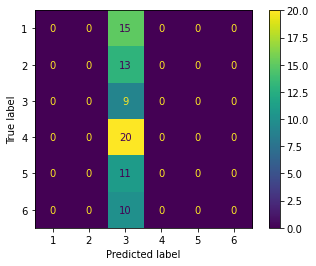

In [152]:
disp_model.plot() 

In [153]:
cm_clf_test=confusion_matrix(Y_test, clf_X_test_pred)

In [154]:
cm_clf_test

array([[15,  0,  0,  0,  0,  0],
       [ 0, 13,  0,  0,  0,  0],
       [ 0,  0,  9,  0,  0,  0],
       [ 0,  0,  0, 20,  0,  0],
       [ 0,  0,  0,  0, 11,  0],
       [ 0,  0,  0,  0,  0, 10]], dtype=int64)

In [155]:
disp_clf = ConfusionMatrixDisplay(confusion_matrix=cm_clf_test, display_labels=model.classes_)

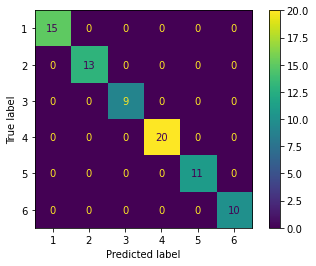

In [156]:
disp_clf.plot() 

In [157]:
cm_knn_test=confusion_matrix(Y_test, knn_X_test_pred)

In [158]:
cm_knn_test

array([[15,  0,  0,  0,  0,  0],
       [ 0,  9,  0,  4,  0,  0],
       [ 0,  0,  9,  0,  0,  0],
       [ 0,  2,  0, 16,  2,  0],
       [ 0,  0,  0,  0, 11,  0],
       [ 0,  0,  0,  0,  0, 10]], dtype=int64)

In [159]:
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn_test, display_labels=model.classes_)

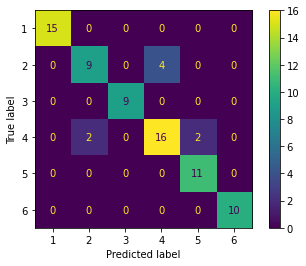

In [160]:
disp_knn.plot()

In [161]:
print(metrics.classification_report(Y_test, clf_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      1.000     1.000     1.000        15
           2      1.000     1.000     1.000        13
           3      1.000     1.000     1.000         9
           4      1.000     1.000     1.000        20
           5      1.000     1.000     1.000        11
           6      1.000     1.000     1.000        10

    accuracy                          1.000        78
   macro avg      1.000     1.000     1.000        78
weighted avg      1.000     1.000     1.000        78



In [162]:
print(metrics.classification_report(Y_test, knn_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      1.000     1.000     1.000        15
           2      0.818     0.692     0.750        13
           3      1.000     1.000     1.000         9
           4      0.800     0.800     0.800        20
           5      0.846     1.000     0.917        11
           6      1.000     1.000     1.000        10

    accuracy                          0.897        78
   macro avg      0.911     0.915     0.911        78
weighted avg      0.897     0.897     0.895        78



In [163]:
print(metrics.classification_report(Y_test, model_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      0.000     0.000     0.000        15
           2      0.000     0.000     0.000        13
           3      0.115     1.000     0.207         9
           4      0.000     0.000     0.000        20
           5      0.000     0.000     0.000        11
           6      0.000     0.000     0.000        10

    accuracy                          0.115        78
   macro avg      0.019     0.167     0.034        78
weighted avg      0.013     0.115     0.024        78



C:\Users\Qwerty\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Qwerty\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Qwerty\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [164]:
#model_cvp=cross_val_predict(model, X_test, Y_test, cv=3, method="predict")

In [165]:
#roc_auc_score(Y_test, model_pred_proba, multi_class='ovr')